# Project 1 

In [44]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import pickle
import matplotlib.pyplot as plt
df = pd.read_csv("../Data/train.csv")

In [45]:
df.head()


,Student_ID,Age,Gender,Degree,Branch,CGPA,Internships,Projects,Coding_Skills,Communication_Skills,Aptitude_Test_Score,Soft_Skills_Rating,Certifications,Backlogs,Placement_Status
0,1048,22,Female,B.Tech,ECE,6.29,0,3,4,6,51,5,1,3,Not Placed
1,37820,20,Female,BCA,ECE,6.05,1,4,6,8,59,8,2,1,Not Placed
2,49668,22,Male,MCA,ME,7.22,1,4,6,6,58,6,2,2,Not Placed
3,19467,22,Male,MCA,ME,7.78,2,4,6,6,90,4,2,0,Placed
4,23094,20,Female,B.Tech,ME,7.63,1,4,6,5,79,6,2,0,Placed


In [46]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Student_ID            45000 non-null  int64  
 1   Age                   45000 non-null  int64  
 2   Gender                45000 non-null  str    
 3   Degree                45000 non-null  str    
 4   Branch                45000 non-null  str    
 5   CGPA                  45000 non-null  float64
 6   Internships           45000 non-null  int64  
 7   Projects              45000 non-null  int64  
 8   Coding_Skills         45000 non-null  int64  
 9   Communication_Skills  45000 non-null  int64  
 10  Aptitude_Test_Score   45000 non-null  int64  
 11  Soft_Skills_Rating    45000 non-null  int64  
 12  Certifications        45000 non-null  int64  
 13  Backlogs              45000 non-null  int64  
 14  Placement_Status      45000 non-null  str    
dtypes: float64(1), int64(10), str(

In [47]:
df.describe()

,Student_ID,Age,CGPA,Internships,Projects,Coding_Skills,Communication_Skills,Aptitude_Test_Score,Soft_Skills_Rating,Certifications,Backlogs
count,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,24977.962600,20.999333,7.002290,0.774089,3.734222,5.691800,5.501644,69.385356,5.501644,1.800956,0.888133
std,14425.605704,1.995071,0.993855,0.844750,0.923738,1.994674,1.515374,13.909710,1.238722,0.650104,0.970954
min,1.000000,18.000000,4.500000,0.000000,1.000000,1.000000,1.000000,35.000000,1.000000,0.000000,0.000000
25%,12509.750000,19.000000,6.320000,0.000000,3.000000,4.000000,4.000000,60.000000,5.000000,1.000000,0.000000
50%,24957.500000,21.000000,7.000000,1.000000,4.000000,6.000000,6.000000,69.000000,5.000000,2.000000,1.000000
75%,37475.250000,23.000000,7.670000,1.000000,4.000000,7.000000,7.000000,79.000000,6.000000,2.000000,2.000000
max,50000.000000,24.000000,9.800000,3.000000,6.000000,10.000000,10.000000,100.000000,10.000000,3.000000,3.000000


In [48]:
df.isnull().sum()

Student_ID              0
Age                     0
Gender                  0
Degree                  0
Branch                  0
CGPA                    0
Internships             0
Projects                0
Coding_Skills           0
Communication_Skills    0
Aptitude_Test_Score     0
Soft_Skills_Rating      0
Certifications          0
Backlogs                0
Placement_Status        0
dtype: int64

In [49]:
# drop col which is not required
df = df.drop("Student_ID", axis=1)

In [50]:
# target variable convert into num
df["Placement_Status"] = df["Placement_Status"].map({
    "Placed": 1,
    "Not Placed": 0
})

In [51]:
# lable encoder
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Gender"] = le.fit_transform(df["Gender"])
df["Degree"] = le.fit_transform(df["Degree"])
df["Branch"] = le.fit_transform(df["Branch"])

In [52]:
print(df.dtypes)

Age                       int64
Gender                    int64
Degree                    int64
Branch                    int64
CGPA                    float64
Internships               int64
Projects                  int64
Coding_Skills             int64
Communication_Skills      int64
Aptitude_Test_Score       int64
Soft_Skills_Rating        int64
Certifications            int64
Backlogs                  int64
Placement_Status          int64
dtype: object


In [53]:
df.to_csv("cleaned_data.csv", index=False)

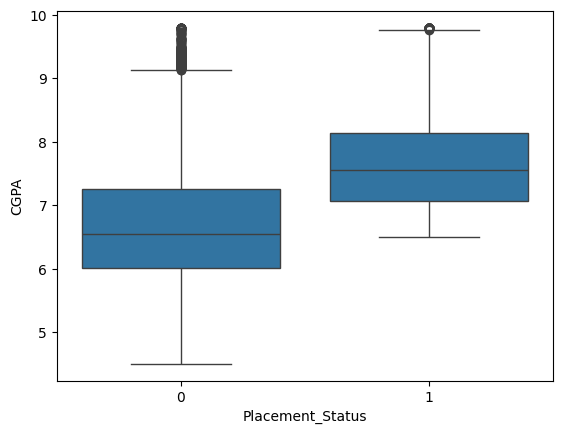

In [54]:
 # This boxplot shows the distribution of CGPA for placed vs not placed students
sns.boxplot(x="Placement_Status", y="CGPA", data=df)
plt.show()

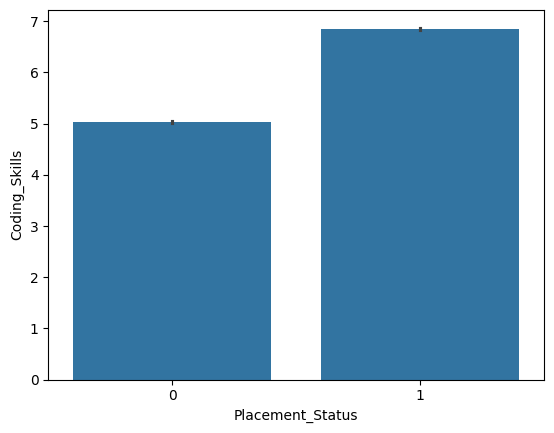

In [55]:
# This barplot shows the average coding skills score for placed vs not placed students
sns.barplot(x="Placement_Status", y="Coding_Skills", data=df)
plt.show()

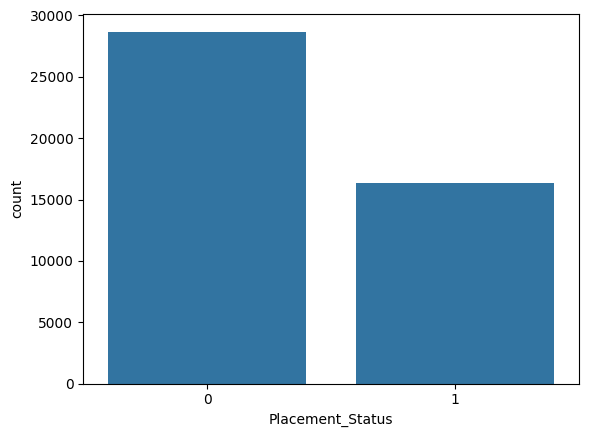

In [56]:
# countplot
sns.countplot(x="Placement_Status", data=df)
plt.show()

In [76]:
# Creating new features to improve model performance

# Average academic score
df["avg_score"] = (df["CGPA"] + df["Internships"] + df["Projects"]) / 3

# Total skills score
df["total_skills"] = df["Aptitude_Test_Score"] + df["Communication_Skills"] + df["Coding_Skills"]

# Weak student flag
df["is_weak"] = df["CGPA"].apply(lambda x: 1 if x < 6 else 0)

In [77]:
features = [
    "CGPA",
    "Internships",
    "Projects",
    "Coding_Skills",
    "Communication_Skills",
    "Aptitude_Test_Score",
    "Backlogs",
    "Degree",
    "Gender",
    "avg_score",
    "total_skills",
    "is_weak"
]

In [78]:
X = df[features]
y = df["Placement_Status"]

In [79]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [80]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [81]:
# Prediction
y_pred = model.predict(X_test)


In [82]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5709
           1       1.00      1.00      1.00      3291

    accuracy                           1.00      9000
   macro avg       1.00      1.00      1.00      9000
weighted avg       1.00      1.00      1.00      9000



In [83]:
def recommend(student):
    recs = []

    if student["CGPA"] < 6:
        recs.append("Focus on improving academic performance (CGPA)")
    elif student["CGPA"] < 7.5:
        recs.append("Try to improve CGPA")

    if student["Coding_Skills"] < 60:
        recs.append("Practice DSA")
    elif student["Coding_Skills"] < 75:
        recs.append("Improve problem solving")

    if student["Communication_Skills"] < 60:
        recs.append("Improve communication")
    elif student["Communication_Skills"] < 75:
        recs.append("Practice speaking")

    if student["Aptitude_Test_Score"] < 60:
        recs.append("Practice aptitude")

    if student["Internships"] == 0:
        recs.append("Do internship")
    elif student["Internships"] == 1:
        recs.append("Do more internships")

    if student["Projects"] < 2:
        recs.append("Build projects")
    elif student["Projects"] < 4:
        recs.append("Build advanced projects")

    if student["Backlogs"] > 0:
        recs.append("Clear backlogs")

    if len(recs) == 0:
        recs.append("You are on track")

    return recs

In [84]:
df["Recommendations"] = df.apply(recommend, axis=1)

In [85]:
# Save Model
pickle.dump(model, open("md.pkl", "wb"))

In [86]:
print(X.columns)
print(X.shape)

Index(['CGPA', 'Internships', 'Projects', 'Coding_Skills',
       'Communication_Skills', 'Aptitude_Test_Score', 'Backlogs', 'Degree',
       'Gender', 'avg_score', 'total_skills', 'is_weak'],
      dtype='str')
(45000, 12)
